# One degree zstar model

This notebook looks at the one degree zstar run of ANU-TUB.
I tried to initialise the model with output from the 0.25 degree version that I interpolated onto the one degree grid but this did not work because of the thickness which caused errors in the SSH.
I am not sure if this was due to remapping to zstar, I used HYCOM model output to generate the initial salinity, or if it was related to the interpolation not conserving things properly.
This may be able to be further explored but for now I have a one year run from an at rest state.
The restart files from Andy and Angus' previous runs were from 500 years.
This one year run took ~55mins and used 75SUs.
Suppposing a single year varies between 75 and 100SUs, need between 37-50KSUs to get to 500 years.

Will think about what best way to go is.

In [5]:
zstar_one_degree_output = "/g/data/e14/jb2381/one-degree-anu-tub/output/zstar"
if pwd() != zstar_one_degree_output
    cd(zstar_one_degree_output)
end

using Pkg
Pkg.activate("..")
using NCDatasets, CairoMakie, NaNStatistics

  Activating project at `/g/data/e14/jb2381/one-degree-anu-tub/output`
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0] (cache misses: wrong dep version loaded (2), dep missing source (6))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling NaNStatistics [b946abbf-3ea7-4610-9019-9858bfdeaf2d] (cache misses: wrong dep version loaded (2), dep missing source (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling NaNStatisticsUnitfulExt [7969ee26-99ae-5bff-9cb8-89f23cc09141] (cache misses: wrong dep version loaded (2), dep missing source (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [6]:
output_path = "/g/data/e14/jb2381/one-degree-anu-tub/control/zstar/archive/output000"

"/g/data/e14/jb2381/one-degree-anu-tub/control/zstar/archive/output000"

## Initial conditions

These are generated and saved; just want to see what they were.

In [7]:
ics = joinpath(output_path, "MOM_IC.nc")

"/g/data/e14/jb2381/one-degree-anu-tub/control/zstar/archive/output000/MOM_IC.nc"

In [12]:
ds = NCDataset(ics, maskingvalue = NaN)
xh = ds["lonh"][:]
yh = ds["lath"][:]
zl = ds["Layer"][:]
θᵢ = ds["Temp"][:, :, :, 1]
close(ds)

closed Dataset

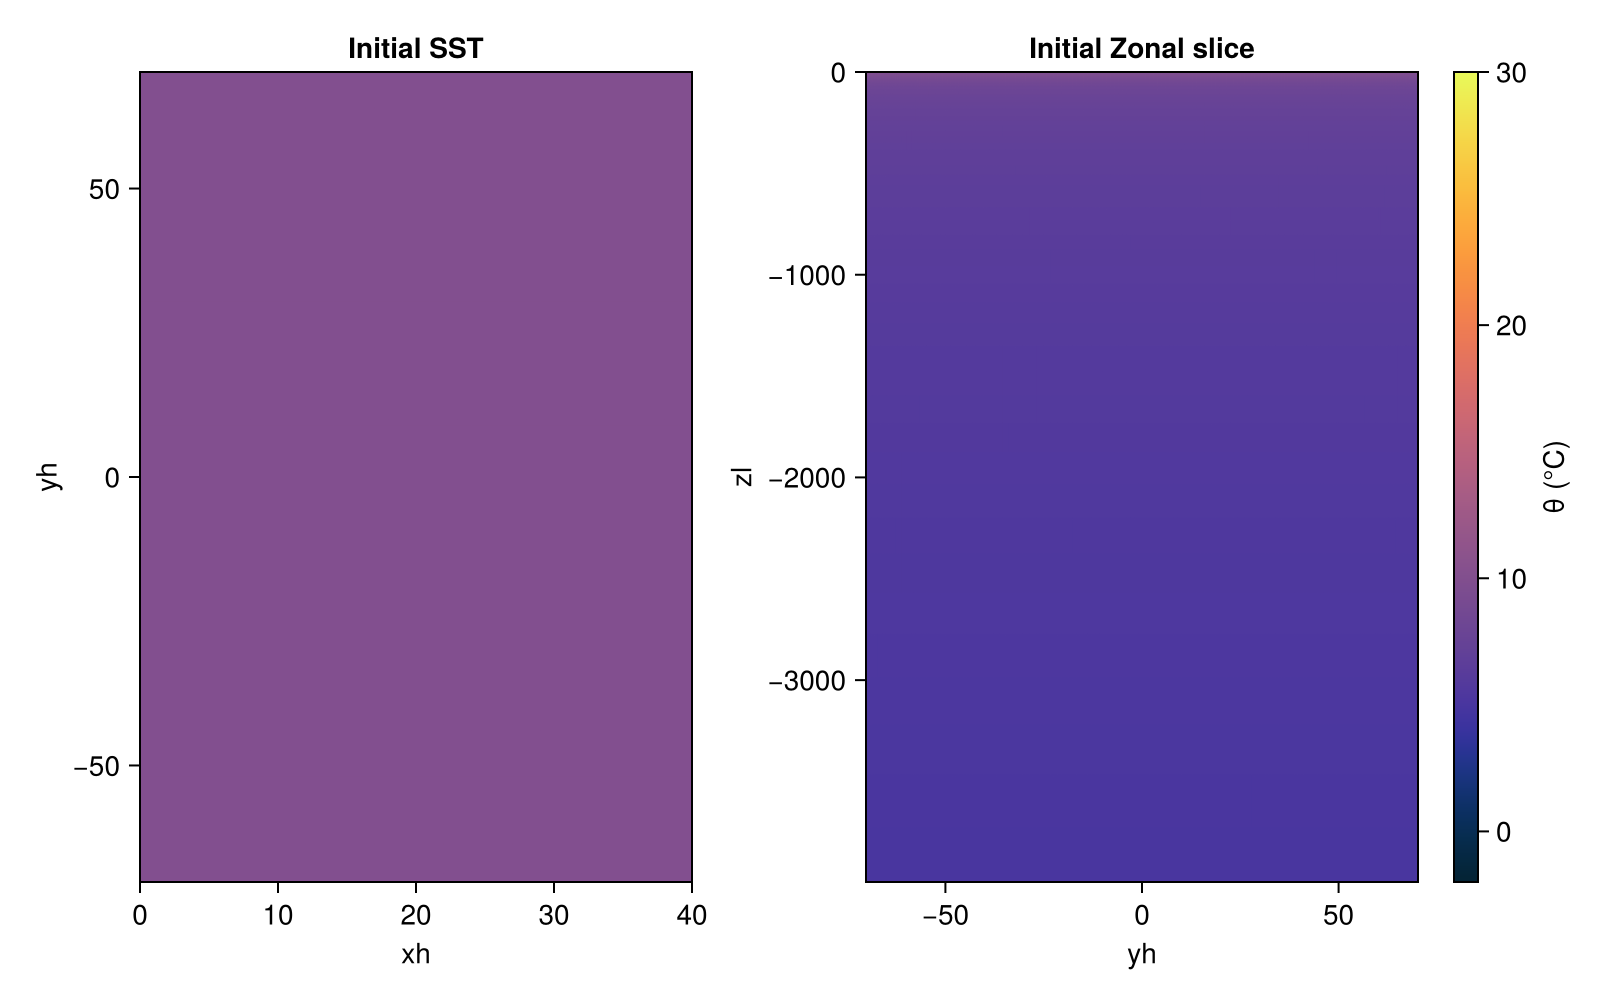

In [19]:
colormap = :thermal
colorrange  = (-2, 30)

fig = Figure(size = (800, 500))

ax = Axis(fig[1, 1], xlabel = "xh", ylabel = "yh", title = "Initial SST")
heatmap!(ax, xh, yh, θᵢ[:, :, 1]; colormap, colorrange)

ax2 = Axis(fig[1, 2], xlabel = "yh", ylabel = "zl", title = "Initial Zonal slice")
hm = heatmap!(ax2, yh, -zl, θᵢ[20, :, :]; colormap, colorrange)

Colorbar(fig[1, 3], hm, label = "θ (°C)")
fig

## Monthly output

In [20]:
monthly = joinpath(output_path, "ocean_month.nc")
zmonthly = joinpath(output_path, "ocean_month_z.nc")

"/g/data/e14/jb2381/one-degree-anu-tub/control/zstar/archive/output000/ocean_month_z.nc"

In [27]:
ds = NCDataset(monthly, maskingvalue = NaN)
h = ds["thkcello"][:, :, :, :]
close(ds)

∫h = cumsum(h, dims = 3)

ds = NCDataset(zmonthly, maskingvalue = NaN)
σ₂ = ds["rhopot2"][:, :, :, :]
close(ds)

closed Dataset

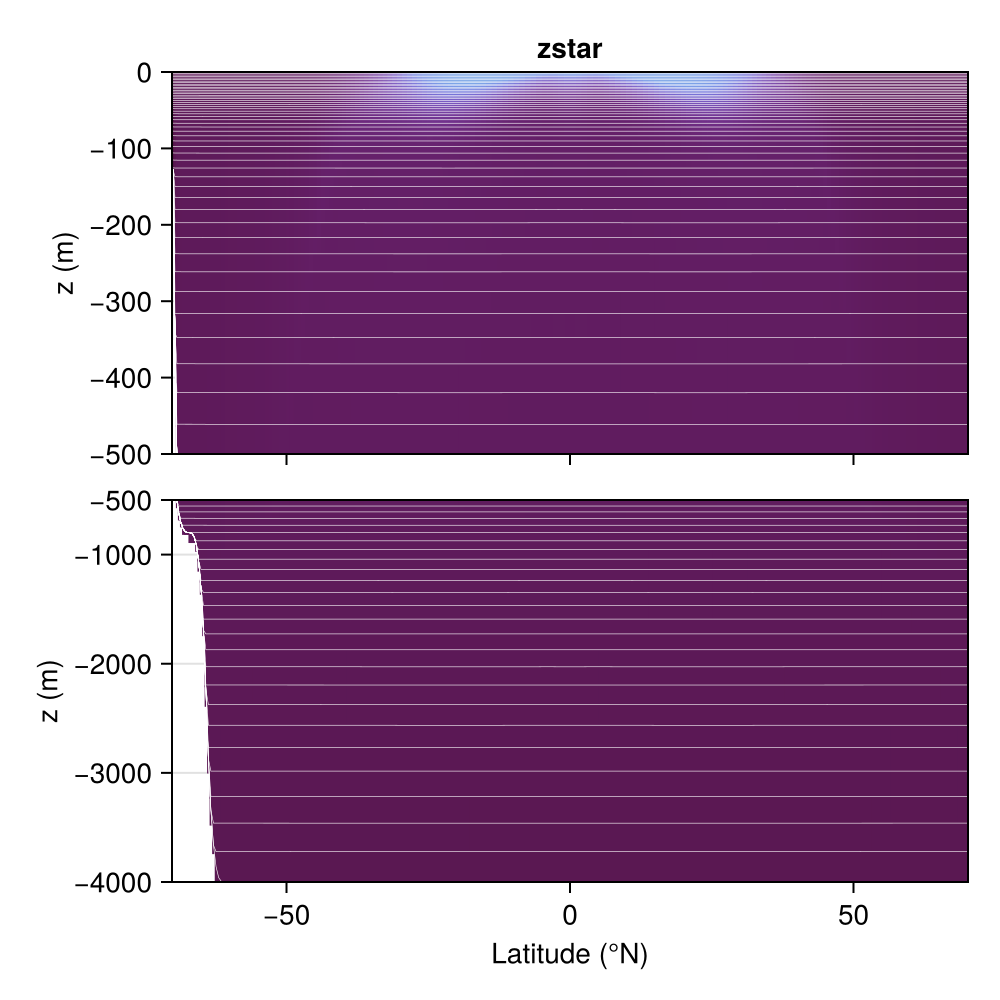

In [31]:
lon = 20
t = 12

fig = Figure(size = (500, 500))

colormap = :dense
colorrange = (1028, 1038)
depth_levels = 1:75

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "zstar")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, -zl, σ₂[lon, :, :, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axtop, yh, -∫h[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axtop, -500, 0)
axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, yh, -zl, σ₂[lon, :, :, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axbot, yh, -∫h[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axbot, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

fig